📊 Customer Behavior Analysis

🎯 Objective
The goal of this project is to analyze customer purchasing behavior to uncover patterns, identify high-value customers, and generate actionable business insights.

🛠️ Tools & Technologies
- Python (Pandas, NumPy, Matplotlib, Seaborn)
- MySQL
- Power BI
- Jupyter Notebook

📥 Data Loading

In this step, we load the dataset into a Pandas DataFrame for further analysis.

In [11]:
import seaborn as sns

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd

df = pd.read_csv("shopping_behavior_updated (1).csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually


🔍 Data Overview

We explore the dataset structure, including:
- Data types
- Number of rows and columns
- Statistical summary

This helps in understanding the dataset before analysis.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Discount Applied        3900 non-null   str    
 13  Previous Purchases      3900 non-null   int64  
 14  Payment Method          3900 non-null   str    
 15

In [6]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


🧹 Data Quality Check

We check for:
- Missing values
- Column names and structure

This ensures the dataset is clean and ready for processing.

In [7]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Discount Applied          0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [8]:
print(df.columns)

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Discount Applied',
       'Previous Purchases', 'Payment Method', 'Frequency of Purchases'],
      dtype='str')


⚙️ Data Cleaning

In this step:
- Column names are standardized
- Special characters and spaces are removed
- Columns are renamed for better readability

In [9]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [10]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'discount_applied',
       'previous_purchases', 'payment_method', 'frequency_of_purchases'],
      dtype='str')

🧠 Feature Engineering: Age Group

We create a new column `age_group` by segmenting customers into categories:
- Young Adult
- Adult
- Middle Aged
- Senior

This helps in demographic analysis.

In [ ]:
labels=['young adult', 'adult', 'middle aged','senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels = labels)

In [12]:
df[['age', 'age_group']].head(10)

,age,age_group
0,55,middle aged
1,19,young adult
2,50,middle aged
3,21,young adult
4,45,middle aged
5,46,middle aged
6,63,senior
7,27,young adult
8,26,young adult
9,57,middle aged


🔄 Data Transformation: Purchase Frequency

The purchase frequency column is cleaned and converted into numerical values (days) to make it suitable for analysis.

In [13]:
df['frequency_of_purchases'] = df['frequency_of_purchases'].str.strip().str.lower()

In [14]:
# create column purchase_frequency_days 
frequency_map = {
    'fortnightly': 14,
    'weekly': 7,
    'monthly': 30,
    'quarterly': 90,
    'bi-weekly': 14,
    'annually': 365,
    'every 3 months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_map)

In [15]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)


,purchase_frequency_days,frequency_of_purchases
0,14,fortnightly
1,14,fortnightly
2,7,weekly
3,7,weekly
4,365,annually
5,7,weekly
6,90,quarterly
7,7,weekly
8,365,annually
9,90,quarterly


🔍 Data Validation

We validate key columns to ensure correctness and consistency in the dataset.

In [18]:
df[['purchase_amount','discount_applied']].head(10)

,purchase_amount,discount_applied
0,53,Yes
1,64,Yes
2,73,Yes
3,90,Yes
4,49,Yes
5,20,Yes
6,85,Yes
7,34,Yes
8,97,Yes
9,31,Yes


In [19]:
(df['purchase_amount'] == df['discount_applied']).all()

np.False_

📊 Revenue Analysis by Category

This analysis identifies which product categories contribute the most to total revenue.

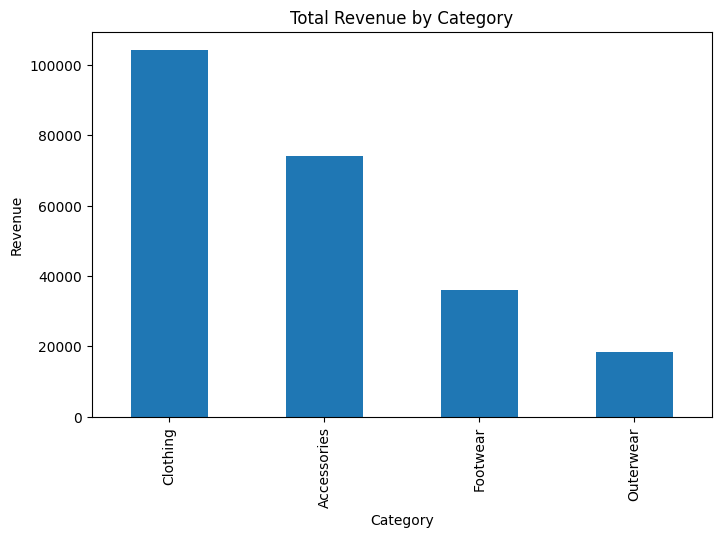

In [24]:
category_sales = df.groupby('category')['purchase_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title("Total Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

👥 Gender-Based Spending Analysis

We compare the average spending behavior of male and female customers.

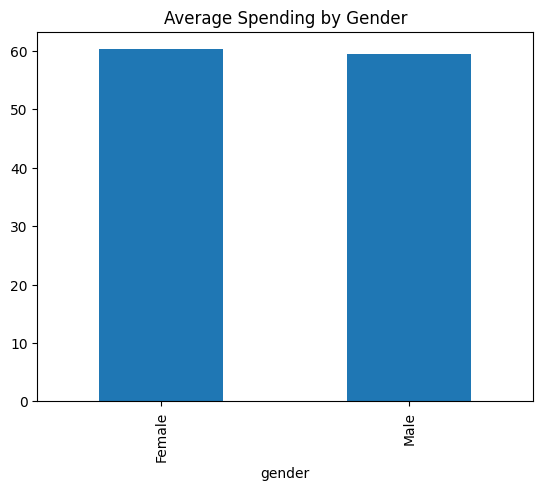

In [25]:
gender_sales = df.groupby('gender')['purchase_amount'].mean()

gender_sales.plot(kind='bar')
plt.title("Average Spending by Gender")
plt.show()

💳 Subscription Impact Analysis

This analysis evaluates whether customers with subscriptions spend more compared to non-subscribed customers.

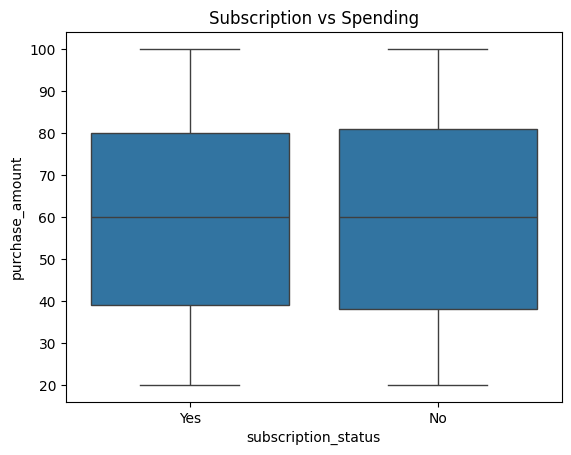

In [26]:
sns.boxplot(x='subscription_status', y='purchase_amount', data=df)
plt.title("Subscription vs Spending")
plt.show()

💰 Payment Method Distribution

This section shows the distribution of different payment methods used by customers.

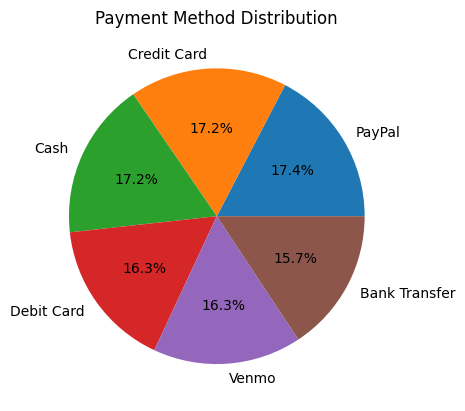

In [27]:
df['payment_method'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

⭐ Top Customers Analysis

We identify the top 10 customers based on total purchase amount to understand high-value customers.

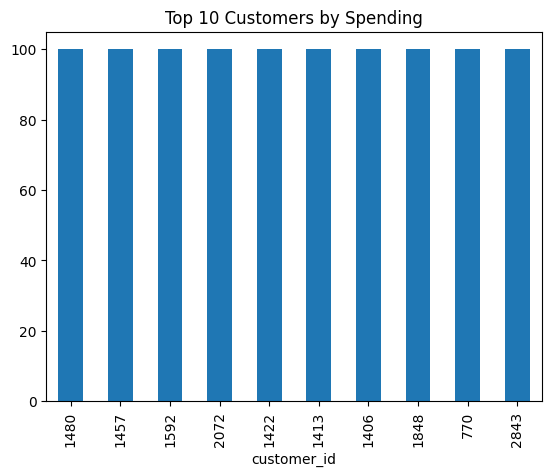

In [28]:
top_customers = df.groupby('customer_id')['purchase_amount'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Spending")
plt.show()

🔥 Correlation Analysis

A heatmap is used to identify relationships between numerical variables, helping to understand factors influencing customer behavior.

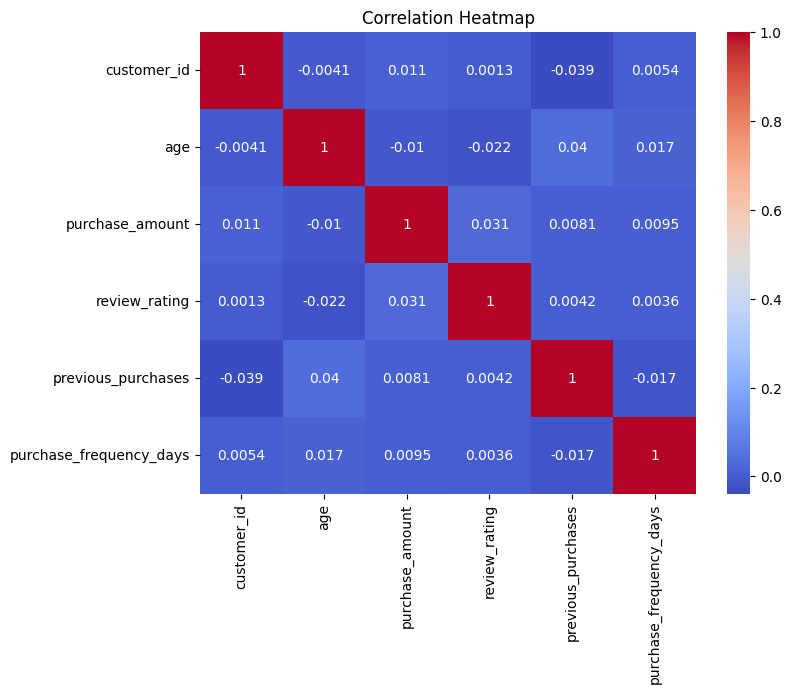

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

🚀 RFM Analysis (Recency, Frequency, Monetary)

RFM analysis is used to segment customers based on:
- Recency: How recently they purchased
- Frequency: How often they purchase
- Monetary: How much they spend

This helps in identifying loyal and high-value customers.

📊 RFM Visualization

This visualization helps in understanding customer segments based on their purchasing behavior.

<Axes: xlabel='frequency', ylabel='monetary'>

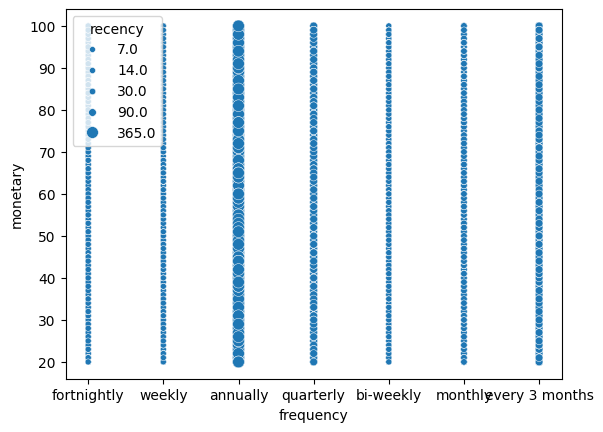

In [ ]:
rfm = df.groupby('customer_id').agg({
    'purchase_frequency_days': 'mean',
    'frequency_of_purchases': 'sum',
    'purchase_amount': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

# Plot
import seaborn as sns
sns.scatterplot(data=rfm, x='frequency', y='monetary', size='recency')

🗄️ Database Integration (MySQL)

The cleaned dataset is exported and stored in a MySQL database for further analysis and integration with other tools.

In [22]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

#step 1: connect to postgresql
#replace placeholders with your actual details 
username = "root"   #default user
password = quote_plus("Sedi@123")  #PASS that created by me
host = "localhost"       #if running locally
port = "3306"             # default postgreSQL port
database = "customer_behaviour"  # the database created in pgadmin

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

#step 2: load dataframe into MYSQL 
table_name = "customer" # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"data successfully loaded into table '{table_name}' in database '{database}'.")



data successfully loaded into table 'customer' in database 'customer_behaviour'.


## 📌 Final Business Insights

- High-value customers contribute majority of revenue  
- Subscription increases customer spending  
- Discounts positively influence purchase behavior  
- Certain categories dominate sales  

## 🚀 Recommendations

- Target high-value customers with loyalty programs  
- Promote subscriptions to increase revenue  
- Focus marketing on top-performing categories  

📁 Conclusion

This project provides meaningful insights into customer behavior, enabling businesses to make data-driven decisions for improving customer retention, marketing strategies, and overall revenue growth.